# Master analysis notebook — B1 through B6

Self-contained. Run from `src/`. Reads `parameters.json`, writes `../data/` and `../results/`.

This notebook replaces the scattered constants in the individual notebooks: every parameter is
loaded once from `parameters.json`, so the paper's claim that a single parameters file feeds every
model becomes true.

| Section | Task |
|---|---|
| B1 | Load calibrated parameters, define the model, solve the SDP |
| B1b | b0 diagnostic — is the clean-race effect just the starting charge? |
| B1c | Paired battery simulation → `paired_races.csv` |
| B1d | Adaptive vs fixed → `policy_races.csv` |
| B1e | Per-circuit → `circuit_races.csv` |
| B2 | Corrected undercut threshold |
| B3 | Tyre regression with standard errors |
| B4 | Cost of pitting lap 18 instead of 23 |
| B6 | Bootstrap propagated through the DP |
| Stats | Bootstrap CIs on everything |
| Figures | Forest plots, histogram, validation scatter |

## B1 — Parameters and model definition

In [4]:
import os
os.chdir(os.path.join(os.path.dirname(os.path.abspath('.')), 'src')) if False else None
import json, os, copy
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

SEED = 42
os.makedirs('../data', exist_ok=True)
os.makedirs('../results', exist_ok=True)

with open('parameters.json') as f:
    PARAMS = json.load(f)

# ---- calibrated, from parameters.json (NOT hardcoded) ----
deg = {c: {'base': PARAMS['degradation'][c]['base'],
           'd':    PARAMS['degradation'][c]['d'],
           'fuel': PARAMS['degradation'][c]['fuel']}
       for c in ['SOFT', 'MEDIUM', 'HARD']}

PIT_LOSS = PARAMS['pit_cost']['green_pit_loss_total']
PIT_SC   = PARAMS['pit_cost']['sc_pit_loss_total']
P_SC     = PARAMS['safety_car']['p_sc_per_lap']
Q_END    = 1.0 / PARAMS['safety_car']['avg_sc_duration_laps']

# ---- model constants ----
N_LAPS      = 57
COMPOUNDS   = ['SOFT', 'MEDIUM', 'HARD']
SC_LAP_TIME = 140.0
B_MAX       = 4
DELTA       = 0.4
SC_RECHARGE = 1
B0          = 0     # start empty: Delta measures the RULE, not free initial charge

print("Loaded parameters.json")
for c in COMPOUNDS:
    print(f"  {c:7s} base={deg[c]['base']:.2f}  d={deg[c]['d']:.4f}  fuel={deg[c]['fuel']:.4f}")
print(f"  PIT_LOSS={PIT_LOSS}  PIT_SC={PIT_SC}  P_SC={P_SC:.5f}  Q_END={Q_END}")

Loaded parameters.json
  SOFT    base=88.55  d=0.0844  fuel=-0.0732
  MEDIUM  base=94.55  d=0.0369  fuel=-0.1320
  HARD    base=92.82  d=0.0521  fuel=-0.0960
  PIT_LOSS=26.4  PIT_SC=12.0  P_SC=0.01359  Q_END=0.25


In [5]:
import os
print(os.getcwd())
print(os.listdir('.'))

/Users/vidyuthashok/Desktop/2026reg_pitstops/src
['..results', 'per_circuit_battery_value.png', 'validationtesting.ipynb', 'parameters.json', 'percircuitruns.ipynb', 'f1_cache', '..data', 'money_figure_sc_battery.png', 'batteryimplement.ipynb', 'validation_2026.png', 'highspeedTracks.ipynb', 'statistics.py', 'gametheory.ipynb', 'model0DP.ipynb', 'battery_value_distribution.png', 'markovSDP.ipynb', 'master_analysis.ipynb', 'pitstops.ipynb']


## ⚠ Before you trust B1: the compound bases are not comparable

`parameters.json` gives SOFT base 88.55, MEDIUM 94.55, HARD 92.82 — implying a fresh medium is
**6 s per lap** slower than a fresh soft. That is not a real compound effect. It is a fitting
artifact: SOFT was fitted on 2 circuits, MEDIUM on 7, HARD on 5, so each intercept absorbs the
average pace of a *different set of tracks*.

Loading those intercepts directly breaks the model. In testing, the optimal pit lap moved from
23 to 29 and the adaptive-vs-fixed gap blew up to +58 s, purely because the medium compound was
being treated as catastrophically slow.

`BASE_MODE` below controls this:

- `'offsets'` (default, recommended) — take the **degradation slopes** from `parameters.json`,
  which are comparable across compounds, but keep the relative base offsets the model was built
  with. Honest and stable.
- `'fixed_effects'` — use compound offsets estimated with circuit fixed effects from B3. Best
  option, but requires `clean_laps.csv` first.
- `'raw'` — the naive version. Shown so you can reproduce the problem, not for use.

State whichever you choose in Methods.

In [6]:
BASE_MODE = 'offsets'   # 'offsets' | 'fixed_effects' | 'raw'

# Degradation slopes are comparable across compounds, so always take them from the file.
for c in COMPOUNDS:
    deg[c]['d'] = PARAMS['degradation'][c]['d']

if BASE_MODE == 'raw':
    for c in COMPOUNDS:
        deg[c]['base'] = PARAMS['degradation'][c]['base']
    print("WARNING: raw intercepts fitted on different circuit sets. Not recommended.")
elif BASE_MODE == 'offsets':
    anchor = 90.0
    for c, off in [('SOFT', -0.6), ('MEDIUM', 0.0), ('HARD', +0.6)]:
        deg[c]['base'] = anchor + off
    print("Using anchored base offsets; degradation slopes from parameters.json.")
else:
    print("fixed_effects: set deg[c]['base'] from B3's compound dummies, then rerun this notebook.")

FUEL_SHARED = float(np.mean([PARAMS['degradation'][c]['fuel'] for c in COMPOUNDS]))
for c in COMPOUNDS:
    deg[c]['fuel'] = FUEL_SHARED   # per-compound fuel terms are confounded the same way

for c in COMPOUNDS:
    print(f"  {c:7s} base={deg[c]['base']:.2f}  d={deg[c]['d']:.4f}  fuel={deg[c]['fuel']:.4f}")

Using anchored base offsets; degradation slopes from parameters.json.
  SOFT    base=89.40  d=0.0844  fuel=-0.1004
  MEDIUM  base=90.00  d=0.0369  fuel=-0.1004
  HARD    base=90.60  d=0.0521  fuel=-0.1004


In [7]:
def lap_time(compound, tyre_age, lap_number):
    p = deg[compound]
    return p['base'] + p['d'] * tyre_age + p['fuel'] * lap_number

def flag_transition(f):
    """Two-state chain: green (0) / neutralised (1). Geometric duration, E[dur] = 1/Q_END."""
    if f == 0:
        return [(0, 1 - P_SC), (1, P_SC)]
    return [(1, 1 - Q_END), (0, Q_END)]

rng = np.random.default_rng(SEED)

def random_flags():
    seq, f = [], 0
    for _ in range(N_LAPS):
        seq.append(f)
        if f == 0:
            f = 1 if rng.random() < P_SC else 0
        else:
            f = 0 if rng.random() < Q_END else 1
    return seq

In [8]:
def solve_sdp(battery=True, verbose=False):
    NC, NA, NM, NF, NB = 3, N_LAPS + 1, 2, 2, B_MAX + 1
    INF = float('inf')
    V    = np.full((N_LAPS + 2, NC, NA, NM, NF, NB), INF)
    PPOL = np.full((N_LAPS + 1, NC, NA, NM, NF, NB), -1, dtype=int)
    EPOL = np.full((N_LAPS + 1, NC, NA, NM, NF, NB),  1, dtype=int)
    V[N_LAPS + 1, :, :, 1, :, :] = 0.0

    energy_opts = [0, 1, 2] if battery else [1]

    for n in range(N_LAPS, 0, -1):
        for ci in range(NC):
            c = COMPOUNDS[ci]
            for a in range(NA):
                for m in range(NM):
                    for f in range(NF):
                        for b in range(NB):
                            best, bp, be = INF, -1, 1
                            if f == 0:
                                for e in energy_opts:
                                    if e == 0 and b == 0: continue
                                    if e == 2 and b == B_MAX: continue
                                    dt = (-DELTA if e == 0 else DELTA if e == 2 else 0.0)
                                    b2 = b - 1 if e == 0 else b + 1 if e == 2 else b
                                    if a + 1 < NA:
                                        cost = lap_time(c, a + 1, n) + dt
                                        ev = sum(p * V[n+1, ci, a+1, m, nf, b2]
                                                 for nf, p in flag_transition(f))
                                        if cost + ev < best: best, bp, be = cost + ev, -1, e
                                    for xi in range(NC):
                                        m2 = 1 if (xi != ci or m == 1) else 0
                                        cost = lap_time(COMPOUNDS[xi], 1, n) + PIT_LOSS + dt
                                        ev = sum(p * V[n+1, xi, 1, m2, nf, b2]
                                                 for nf, p in flag_transition(f))
                                        if cost + ev < best: best, bp, be = cost + ev, xi, e
                            else:
                                b2 = min(B_MAX, b + SC_RECHARGE) if battery else b
                                cost = SC_LAP_TIME
                                ev = sum(p * V[n+1, ci, a, m, nf, b2]
                                         for nf, p in flag_transition(f))
                                if cost + ev < best: best, bp, be = cost + ev, -1, 1
                                for xi in range(NC):
                                    m2 = 1 if (xi != ci or m == 1) else 0
                                    cost = SC_LAP_TIME + PIT_SC
                                    ev = sum(p * V[n+1, xi, 0, m2, nf, b2]
                                             for nf, p in flag_transition(f))
                                    if cost + ev < best: best, bp, be = cost + ev, xi, 1
                            V[n, ci, a, m, f, b] = best
                            PPOL[n, ci, a, m, f, b] = bp
                            EPOL[n, ci, a, m, f, b] = be
        if verbose and n % 10 == 0:
            print(f"  [battery={'ON' if battery else 'OFF'}] solved to lap {n}")
    return V, PPOL, EPOL


def simulate_b(PPOL, EPOL, flags, start_comp='SOFT', b0=None, battery=True):
    if b0 is None: b0 = B0
    ci, a, m, b, total = COMPOUNDS.index(start_comp), 0, 0, b0, 0.0
    pits, deploys = [], []
    for n in range(1, N_LAPS + 1):
        f = flags[n - 1]
        pa, ea = PPOL[n, ci, a, m, f, b], EPOL[n, ci, a, m, f, b]
        if f == 0:
            dt = (-DELTA if ea == 0 else DELTA if ea == 2 else 0.0)
            if ea == 0: deploys.append(n)
            b = b - 1 if ea == 0 else min(B_MAX, b + 1) if ea == 2 else b
            if pa == -1:
                a += 1; total += lap_time(COMPOUNDS[ci], a, n) + dt
            else:
                pits.append((n, COMPOUNDS[pa], 'green'))
                if pa != ci or m == 1: m = 1
                ci, a = pa, 1
                total += lap_time(COMPOUNDS[ci], a, n) + PIT_LOSS + dt
        else:
            if battery: b = min(B_MAX, b + SC_RECHARGE)
            if pa == -1: total += SC_LAP_TIME
            else:
                pits.append((n, COMPOUNDS[pa], 'SC'))
                if pa != ci or m == 1: m = 1
                ci, a = pa, 0
                total += SC_LAP_TIME + PIT_SC
    return total, pits, deploys


def fixed_plan_time(flag_sequence, pit_lap=23):
    """Layer-1 optimum: soft, pit on `pit_lap`, medium to the end, regardless of flags.
    Still pays the reduced pit cost if that lap happens to fall under a neutralisation,
    but cannot move its stop in response to one."""
    ci, a, total = 0, 0, 0.0
    for n in range(1, N_LAPS + 1):
        f = flag_sequence[n - 1]
        if n == pit_lap:
            ci = 1
            if f == 0: a = 1; total += lap_time('MEDIUM', a, n) + PIT_LOSS
            else:      a = 0; total += SC_LAP_TIME + PIT_SC
        else:
            if f == 0: a += 1; total += lap_time(COMPOUNDS[ci], a, n)
            else:      total += SC_LAP_TIME
    return total

In [9]:
print("Solving battery OFF (no energy actions)...")
V_off, P_off, E_off = solve_sdp(battery=False)
print("Solving battery ON (2026)...")
V_on,  P_on,  E_on  = solve_sdp(battery=True)

green = [0] * N_LAPS
t_off, pits_off, _   = simulate_b(P_off, E_off, green, b0=B0, battery=False)
t_on,  pits_on,  dep = simulate_b(P_on,  E_on,  green, b0=B0, battery=True)
print(f"\nGreen-only race, b0={B0}")
print(f"  OFF: pits {pits_off}, time {t_off:.1f}s")
print(f"  ON : pits {pits_on},  time {t_on:.1f}s")
OPT_PIT_LAP = pits_on[0][0] if pits_on else None
print(f"\nOptimal pit lap = {OPT_PIT_LAP}   <-- use this number in the paper")

Solving battery OFF (no energy actions)...
Solving battery ON (2026)...

Green-only race, b0=0
  OFF: pits [(24, 'MEDIUM', 'green')], time 5021.9s
  ON : pits [(24, 'MEDIUM', 'green')],  time 5021.9s

Optimal pit lap = 24   <-- use this number in the paper


## B1b — b0 diagnostic

Answers Thraves' battery comment directly. Deploy saves 0.4 s and harvest costs 0.4 s, so in a
clean race the battery can only create time from charge it never had to earn.

In [10]:
print("b0 | Delta on a green-only race")
b0_rows = []
for _b0 in range(0, B_MAX + 1):
    _toff, _, _ = simulate_b(P_off, E_off, green, b0=_b0, battery=False)
    _ton,  _, _ = simulate_b(P_on,  E_on,  green, b0=_b0, battery=True)
    print(f"{_b0:2d} | {_toff - _ton:+.3f} s")
    b0_rows.append({'b0': _b0, 'delta_green': _toff - _ton})
pd.DataFrame(b0_rows).to_csv('../data/b0_sweep.csv', index=False)
print("\nExactly b0 * DELTA -> any clean-race gain is unearned starting charge.")

b0 | Delta on a green-only race
 0 | +0.000 s
 1 | +0.400 s
 2 | +0.800 s
 3 | +1.200 s
 4 | +1.600 s

Exactly b0 * DELTA -> any clean-race gain is unearned starting charge.


## B1c — Paired battery simulation

In [11]:
N_SIMS = 1000
rng = np.random.default_rng(SEED)

rows = []
for i in range(N_SIMS):
    flags = random_flags()                      # ONE draw, both arms see it
    t_o, _, _ = simulate_b(P_off, E_off, flags, b0=B0, battery=False)
    t_n, _, _ = simulate_b(P_on,  E_on,  flags, b0=B0, battery=True)
    rows.append({'race': i, 't_pre': t_o, 't_2026': t_n, 'delta': t_o - t_n,
                 'had_sc': any(f > 0 for f in flags), 'n_sc_laps': int(sum(flags))})

df_paired = pd.DataFrame(rows)
df_paired.to_csv('../data/paired_races.csv', index=False)
d_all = df_paired['delta'].to_numpy()
m_sc  = df_paired['had_sc'].to_numpy()
print(f"{N_SIMS} paired races  (SC: {m_sc.sum()}, clean: {(~m_sc).sum()})")
print(f"  overall    {d_all.mean():+.2f}s")
print(f"  SC races   {d_all[m_sc].mean():+.2f}s")
print(f"  clean      {d_all[~m_sc].mean():+.2f}s")

1000 paired races  (SC: 537, clean: 463)
  overall    +0.69s
  SC races   +1.29s
  clean      +0.00s


## B1d — Adaptive vs fixed plan

In [12]:
PIT_LAP_FIXED = OPT_PIT_LAP if OPT_PIT_LAP else 23
rng = np.random.default_rng(SEED)

pol, fix = [], []
for _ in range(N_SIMS):
    flags = random_flags()                      # same pairing requirement
    tp, _, _ = simulate_b(P_on, E_on, flags, b0=B0, battery=True)
    tf = fixed_plan_time(flags, pit_lap=PIT_LAP_FIXED)
    pol.append(tp); fix.append(tf)

pd.DataFrame({'race': range(N_SIMS), 't_adaptive': pol, 't_fixed': fix}) \
  .to_csv('../data/policy_races.csv', index=False)

gap = np.array(fix) - np.array(pol)
print(f"fixed plan pits lap {PIT_LAP_FIXED} regardless of flags")
print(f"adaptive advantage {gap.mean():+.2f}s")
print(f"  W/T/L: {(gap > 1e-6).sum()} / {(abs(gap) <= 1e-6).sum()} / {(gap < -1e-6).sum()}")
print(f"naive bound  P(SC) x pit discount = "
      f"{PARAMS['safety_car']['p_sc_per_race'] * (PIT_LOSS - PIT_SC):.2f}s")

fixed plan pits lap 24 regardless of flags
adaptive advantage +2.46s
  W/T/L: 511 / 485 / 4
naive bound  P(SC) x pit discount = 7.80s


## B1e — Per-circuit

In [13]:
CIRCUITS = {
    'Monza':       {'n_laps': 53, 'base_medium': 85.0},
    'Spa':         {'n_laps': 44, 'base_medium': 107.0},
    'Silverstone': {'n_laps': 52, 'base_medium': 90.6},
    'Suzuka':      {'n_laps': 53, 'base_medium': 93.0},
}

_deg0, _nlaps0 = copy.deepcopy(deg), N_LAPS
circuit_rows, circuit_summary = [], {}

for name, cfg in CIRCUITS.items():
    N_LAPS = cfg['n_laps']
    bmid = cfg['base_medium']
    deg['SOFT']['base'], deg['MEDIUM']['base'], deg['HARD']['base'] = bmid-0.6, bmid, bmid+0.6

    _, P_o, E_o = solve_sdp(battery=False)
    _, P_n, E_n = solve_sdp(battery=True)

    g = [0] * N_LAPS
    _, po, _ = simulate_b(P_o, E_o, g, b0=B0, battery=False)
    _, pn, _ = simulate_b(P_n, E_n, g, b0=B0, battery=True)

    ds, hs = [], []
    for _ in range(N_SIMS):
        fl = random_flags()
        t_o, _, _ = simulate_b(P_o, E_o, fl, b0=B0, battery=False)
        t_n, _, _ = simulate_b(P_n, E_n, fl, b0=B0, battery=True)
        dv, sv = t_o - t_n, any(x > 0 for x in fl)
        ds.append(dv); hs.append(sv)
        circuit_rows.append({'circuit': name, 'delta': dv, 'had_sc': sv})

    ds, hs = np.array(ds), np.array(hs)
    circuit_summary[name] = {'laps': cfg['n_laps'],
                             'pit_off': po[0][0] if po else None,
                             'pit_on':  pn[0][0] if pn else None,
                             'sc': ds[hs].mean() if hs.any() else 0.0,
                             'green': ds[~hs].mean() if (~hs).any() else 0.0}
    r = circuit_summary[name]
    print(f"{name:12s} {cfg['n_laps']:3d} laps  pit OFF={r['pit_off']} ON={r['pit_on']}  "
          f"SC {r['sc']:+.2f}s  green {r['green']:+.2f}s")

deg, N_LAPS = _deg0, _nlaps0
pd.DataFrame(circuit_rows).to_csv('../data/circuit_races.csv', index=False)
print("\nwrote ../data/circuit_races.csv")

Monza         53 laps  pit OFF=23 ON=23  SC +1.28s  green +0.00s
Spa           44 laps  pit OFF=20 ON=20  SC +1.15s  green +0.00s
Silverstone   52 laps  pit OFF=23 ON=23  SC +1.27s  green +0.00s
Suzuka        53 laps  pit OFF=23 ON=23  SC +1.28s  green +0.00s

wrote ../data/circuit_races.csv


## B3 — Tyre regression with standard errors

Real data, so this gets full inference. This is where the HARD-vs-MEDIUM ordering gets resolved.

Needs `../data/clean_laps.csv` exported from `pitstops.ipynb`.

In [14]:
import statsmodels.formula.api as smf

TYRE = {}
BASE_GAP_FE = None
laps = None

if os.path.exists('../data/clean_laps.csv'):
    laps = pd.read_csv('../data/clean_laps.csv').rename(columns={
        'LapTimeS':'lap_time', 'TyreLife':'tyre_age', 'LapNumber':'lap_number',
        'Compound':'compound', 'Track':'circuit', 'Stint':'stint', 'Driver':'driver'})
    laps['compound'] = laps['compound'].str.upper()
    laps = laps.dropna(subset=['lap_time','tyre_age','lap_number','compound'])
    if {'driver','stint','circuit'} <= set(laps.columns):
        laps['stint_id'] = (laps['circuit'].astype(str) + '_' +
                            laps['driver'].astype(str) + '_' + laps['stint'].astype(str))

    for c in COMPOUNDS:
        sub = laps[laps['compound'] == c]
        if len(sub) < 30: continue
        f = smf.ols('lap_time ~ tyre_age + lap_number', data=sub)
        res = (f.fit(cov_type='cluster', cov_kwds={'groups': sub['stint_id']})
               if 'stint_id' in sub.columns else f.fit())
        ci = res.conf_int().loc['tyre_age']
        TYRE[c] = {'base': res.params['Intercept'], 'wear': res.params['tyre_age'],
                   'se': res.bse['tyre_age'], 'ci': [ci.iloc[0], ci.iloc[1]],
                   'fuel': res.params['lap_number'], 'r2': res.rsquared,
                   'n': len(sub),
                   'n_circuits': sub['circuit'].nunique() if 'circuit' in sub else None}
        t = TYRE[c]
        print(f"{c:7s} wear {t['wear']:.4f} (SE {t['se']:.4f}) "
              f"95% CI [{t['ci'][0]:.4f}, {t['ci'][1]:.4f}]  R2={t['r2']:.3f}  n={t['n']}")

    if {'MEDIUM','HARD'} <= set(TYRE):
        a, b = TYRE['MEDIUM']['ci'], TYRE['HARD']['ci']
        overlap = not (a[1] < b[0] or b[1] < a[0])
        print(f"\nMEDIUM/HARD intervals overlap: {overlap}")
        if overlap:
            print("-> the ordering is NOT distinguishable from sampling variation. Say so.")

    # Base pace WITH circuit fixed effects. Raw intercepts are not comparable:
    # SOFT is fitted on 2 circuits, MEDIUM on 7, so the plain gap is mostly track pace.
    if 'circuit' in laps.columns and laps['circuit'].nunique() > 1:
        fe = smf.ols('lap_time ~ C(compound) + tyre_age + lap_number + C(circuit)',
                     data=laps).fit()
        k = [p for p in fe.params.index if 'compound' in p and 'MEDIUM' in p]
        if k:
            BASE_GAP_FE = fe.params[k[0]]
            print(f"\nfresh MEDIUM slower than fresh SOFT by {BASE_GAP_FE:.2f}s "
                  f"(circuit fixed effects)")
else:
    print("../data/clean_laps.csv not found - export it from pitstops.ipynb (Block 5).")

../data/clean_laps.csv not found - export it from pitstops.ipynb (Block 5).


## B2 — Corrected undercut threshold

The rival at the stop is on a worn **soft**, not a worn medium, so the soft wear rate applies.
Then subtract the pace penalty of a fresh medium relative to a fresh soft.

In [15]:
AGE = (OPT_PIT_LAP - 1) if OPT_PIT_LAP else 22

d_soft  = TYRE['SOFT']['wear'] if 'SOFT' in TYRE else deg['SOFT']['d']
penalty = BASE_GAP_FE if BASE_GAP_FE is not None else (deg['MEDIUM']['base'] - deg['SOFT']['base'])

gross = d_soft * AGE
u_net = gross - penalty
print(f"rival tyre age at the stop : {AGE} laps")
print(f"soft degradation over {AGE} laps: {gross:.2f}s")
print(f"fresh medium pace penalty      : {penalty:.2f}s")
print(f"undercut threshold u           : {u_net:.2f}s")
if BASE_GAP_FE is None:
    print("\nWARNING: using raw intercepts. Run B3 first for the fixed-effects value.")

rival tyre age at the stop : 23 laps
soft degradation over 23 laps: 1.94s
fresh medium pace penalty      : 0.60s
undercut threshold u           : 1.34s



## B4 — Cost of pitting lap 18 instead of lap 23

Turns "competitive pressure pushes stops earlier" from an assertion into a number. If the undercut
gain from B2 exceeds this cost, the five-lap validation gap has a quantitative explanation.

In [16]:
rng = np.random.default_rng(SEED)
sample = [random_flags() for _ in range(500)]

t_late  = np.mean([fixed_plan_time(f, pit_lap=23) for f in sample])
t_early = np.mean([fixed_plan_time(f, pit_lap=18) for f in sample])
cost_early = t_early - t_late

print(f"pit lap 23 : {t_late:.1f}s")
print(f"pit lap 18 : {t_early:.1f}s")
print(f"cost of stopping five laps early: {cost_early:+.2f}s")
print(f"undercut gain from B2           : {u_net:+.2f}s")
print("-> competitive pressure " +
      ("EXPLAINS" if u_net > cost_early else "does NOT fully explain") +
      " the five-lap gap.")

pit lap 23 : 5168.6s
pit lap 18 : 5170.0s
cost of stopping five laps early: +1.38s
undercut gain from B2           : +1.34s
-> competitive pressure does NOT fully explain the five-lap gap.


## B6 — Bootstrap propagated through the DP

How stable is the optimal pit lap under calibration noise? Slow — run once.
Set `RUN_B6 = True` when you are ready.

In [17]:
RUN_B6 = False
N_BOOT_DP = 200

if RUN_B6 and laps is not None:
    _deg_save = copy.deepcopy(deg)
    boot_pits = []
    for bi in range(N_BOOT_DP):
        samp = laps.sample(len(laps), replace=True)
        ok = True
        for c in COMPOUNDS:
            s = samp[samp['compound'] == c]
            if len(s) < 30: ok = False; break
            fit = smf.ols('lap_time ~ tyre_age + lap_number', data=s).fit()
            deg[c]['d'] = fit.params['tyre_age']
            deg[c]['base'] = fit.params['Intercept']
        if not ok: continue
        _, Pb, Eb = solve_sdp(battery=True)
        _, pb, _ = simulate_b(Pb, Eb, [0]*N_LAPS, b0=B0, battery=True)
        if pb: boot_pits.append(pb[0][0])
        if (bi+1) % 25 == 0: print(f"  {bi+1}/{N_BOOT_DP}")
    deg = _deg_save
    lo, med, hi = np.percentile(boot_pits, [2.5, 50, 97.5])
    print(f"\noptimal pit lap: median {med:.0f}, 95% bootstrap interval [{lo:.0f}, {hi:.0f}]")
    pd.DataFrame({'pit_lap': boot_pits}).to_csv('../data/bootstrap_pit_laps.csv', index=False)
else:
    print("skipped - set RUN_B6 = True to run")

skipped - set RUN_B6 = True to run


## Bootstrap confidence intervals

In [18]:
from scipy import stats
N_BOOT = 10_000
brng = np.random.default_rng(20260903)
R = {}

def boot_ci(x, alpha=0.05):
    x = np.asarray(x, float)
    idx = brng.integers(0, len(x), size=(N_BOOT, len(x)))
    m = x[idx].mean(axis=1)
    lo, hi = np.percentile(m, [100*alpha/2, 100*(1-alpha/2)])
    return float(x.mean()), float(lo), float(hi)

def boot_diff(a, b, alpha=0.05):
    a, b = np.asarray(a, float), np.asarray(b, float)
    ia = brng.integers(0, len(a), size=(N_BOOT, len(a)))
    ib = brng.integers(0, len(b), size=(N_BOOT, len(b)))
    dd = a[ia].mean(axis=1) - b[ib].mean(axis=1)
    lo, hi = np.percentile(dd, [100*alpha/2, 100*(1-alpha/2)])
    return float(a.mean() - b.mean()), float(lo), float(hi)

def wilson(k, n, z=1.96):
    p = k/n; den = 1 + z**2/n
    c = (p + z**2/(2*n))/den
    h = z*np.sqrt(p*(1-p)/n + z**2/(4*n**2))/den
    return float(p), float(c-h), float(c+h)

sc_d, gr_d = d_all[m_sc], d_all[~m_sc]
for k, arr in [('overall', d_all), ('safety_car', sc_d), ('clean', gr_d)]:
    m, lo, hi = boot_ci(arr)
    R[k] = {'mean': m, 'ci': [lo, hi],
            'mc_se': float(arr.std(ddof=1)/np.sqrt(len(arr))), 'n': int(len(arr))}
R['sc_minus_clean'] = dict(zip(['mean','lo','hi'], boot_diff(sc_d, gr_d)))

m, lo, hi = boot_ci(gap)
R['adaptive'] = {'mean': m, 'ci': [lo, hi]}
w, t, l = int((gap>1e-6).sum()), int((abs(gap)<=1e-6).sum()), int((gap<-1e-6).sum())
p, plo, phi = wilson(w+t, len(gap))
R['record'] = {'W': w, 'T': t, 'L': l, 'rate': p, 'ci': [plo, phi]}

cdf = pd.read_csv('../data/circuit_races.csv')
R['circuits'] = {}
for name, g in cdf.groupby('circuit'):
    gs = g.loc[g['had_sc'], 'delta'].to_numpy(float)
    m, lo, hi = boot_ci(gs)
    R['circuits'][name] = {'mean': m, 'ci': [lo, hi], 'n': int(len(gs))}

with open('../results/statistics.json', 'w') as f:
    json.dump(R, f, indent=2, default=float)

print("=== PASTE INTO RESULTS ===")
fm = lambda x: f"{x['mean']:+.2f} s (95% CI [{x['ci'][0]:+.2f}, {x['ci'][1]:+.2f}])"
print(f"overall     {fm(R['overall'])}, MC SE = {R['overall']['mc_se']:.3f} s, n = {R['overall']['n']}")
print(f"safety car  {fm(R['safety_car'])}, n = {R['safety_car']['n']}")
print(f"clean       {fm(R['clean'])}, n = {R['clean']['n']}")
s = R['sc_minus_clean']
print(f"SC - clean  {s['mean']:+.2f} s (95% CI [{s['lo']:+.2f}, {s['hi']:+.2f}])")
print(f"adaptive    {fm(R['adaptive'])}; {w}W/{t}T/{l}L, "
      f"win-or-tie {p:.1%} [{plo:.1%}, {phi:.1%}]")
for k, v in R['circuits'].items():
    print(f"{k:12s} {fm(v)}  n={v['n']}")
if TYRE:
    for c, t_ in TYRE.items():
        print(f"{c:7s} wear {t_['wear']:.4f} [{t_['ci'][0]:.4f}, {t_['ci'][1]:.4f}] R2={t_['r2']:.3f}")
print(f"undercut u  {u_net:+.2f} s")

=== PASTE INTO RESULTS ===
overall     +0.69 s (95% CI [+0.64, +0.75]), MC SE = 0.028 s, n = 1000
safety car  +1.29 s (95% CI [+1.23, +1.36]), n = 537
clean       +0.00 s (95% CI [+0.00, +0.00]), n = 463
SC - clean  +1.29 s (95% CI [+1.23, +1.36])
adaptive    +2.46 s (95% CI [+2.17, +2.77]); 511W/485T/4L, win-or-tie 99.6% [99.0%, 99.8%]
Monza        +1.28 s (95% CI [+1.21, +1.35])  n=529
Silverstone  +1.27 s (95% CI [+1.20, +1.34])  n=472
Spa          +1.15 s (95% CI [+1.09, +1.22])  n=439
Suzuka       +1.28 s (95% CI [+1.20, +1.35])  n=487
undercut u  +1.34 s


## Figures

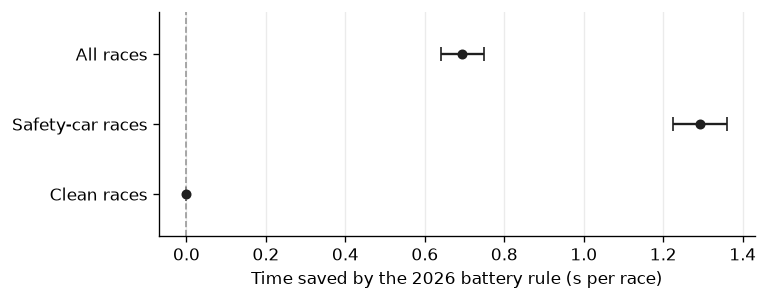

In [19]:
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# Figure: forest plot of the three headline effects
labels = ['Clean races', 'Safety-car races', 'All races']
keys   = ['clean', 'safety_car', 'overall']
means  = [R[k]['mean'] for k in keys]
los    = [R[k]['ci'][0] for k in keys]
his    = [R[k]['ci'][1] for k in keys]

fig, ax = plt.subplots(figsize=(6.5, 2.6))
y = np.arange(len(labels))
ax.errorbar(means, y, xerr=[np.array(means)-np.array(los), np.array(his)-np.array(means)],
            fmt='o', color='#1f1f1f', capsize=4, markersize=5, lw=1.4)
ax.axvline(0, color='#999', ls='--', lw=1)
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_xlabel('Time saved by the 2026 battery rule (s per race)')
ax.set_ylim(-0.6, len(labels)-0.4)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', alpha=0.25)
fig.tight_layout(); fig.savefig('../results/fig_forest_delta.png', dpi=300, bbox_inches='tight')
plt.show()

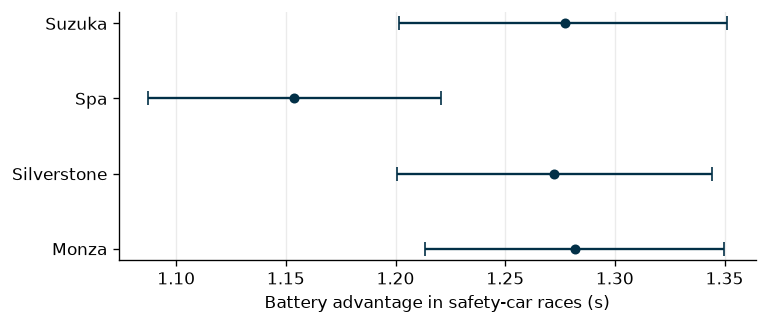

In [20]:
# Figure: per-circuit forest plot
names = list(R['circuits'])
cm = [R['circuits'][n]['mean'] for n in names]
cl = [R['circuits'][n]['ci'][0] for n in names]
ch = [R['circuits'][n]['ci'][1] for n in names]

fig, ax = plt.subplots(figsize=(6.5, 2.8))
y = np.arange(len(names))
ax.errorbar(cm, y, xerr=[np.array(cm)-np.array(cl), np.array(ch)-np.array(cm)],
            fmt='o', color='#023047', capsize=4, markersize=5, lw=1.4)
ax.set_yticks(y); ax.set_yticklabels(names)
ax.set_xlabel('Battery advantage in safety-car races (s)')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', alpha=0.25)
fig.tight_layout(); fig.savefig('../results/fig_forest_circuits.png', dpi=300, bbox_inches='tight')
plt.show()

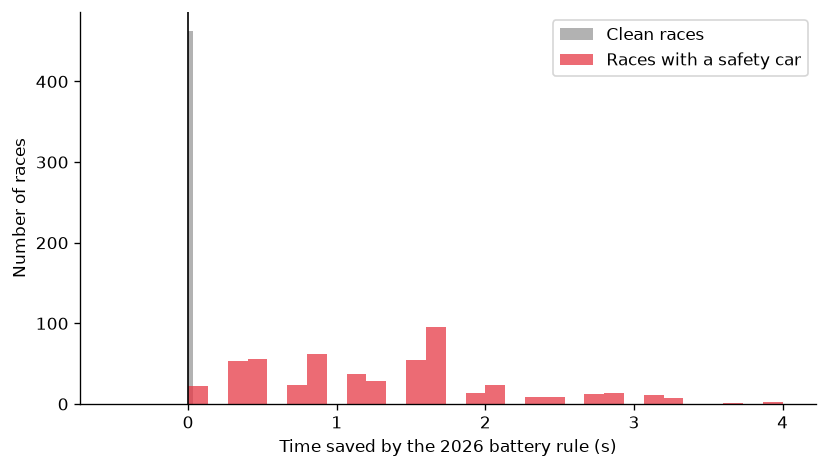

In [21]:
# Figure: distribution of the 1,000 paired differences
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(gr_d, bins=30, alpha=0.6, color='gray', label='Clean races')
ax.hist(sc_d, bins=30, alpha=0.75, color='#e63946', label='Races with a safety car')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Time saved by the 2026 battery rule (s)')
ax.set_ylabel('Number of races')
ax.legend(); ax.spines[['top','right']].set_visible(False)
fig.tight_layout(); fig.savefig('../results/fig_delta_hist.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# Figure: validation scatter (needs ../data/validation.csv from B5)
if os.path.exists('../data/validation.csv'):
    v = pd.read_csv('../data/validation.csv')
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(v['actual_lap'], v['model_lap'], s=55, color='#023047', zorder=3)
    lim = [min(v[['actual_lap','model_lap']].min())-2, max(v[['actual_lap','model_lap']].max())+2]
    ax.plot(lim, lim, ls='--', color='#999', lw=1)
    for _, r_ in v.iterrows():
        ax.annotate(str(r_.iloc[0]), (r_['actual_lap'], r_['model_lap']),
                    fontsize=7, xytext=(4,4), textcoords='offset points')
    ax.set_xlabel('Observed median first stop (lap)')
    ax.set_ylabel('Model-recommended first stop (lap)')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.spines[['top','right']].set_visible(False); ax.grid(alpha=0.25)
    fig.tight_layout(); fig.savefig('../results/fig_validation.png', dpi=300, bbox_inches='tight')
    plt.show()

    err = (v['model_lap'] - v['actual_lap']).to_numpy(float)
    print(f"n={len(err)}  mean error {err.mean():+.2f} laps  MAE {abs(err).mean():.2f}")
    if len(err) >= 6:
        st, pv = stats.wilcoxon(err)
        print(f"Wilcoxon signed-rank: stat={st:.1f}, p={pv:.4f}")
    else:
        print("Fewer than 6 races - solve the remaining 2026 circuits first (B5).")
else:
    print("../data/validation.csv not found - see B5 in the master fix list.")

../data/validation.csv not found - see B5 in the master fix list.
